12/09/2026
First version

In [1]:
from io import StringIO, TextIOWrapper
from pathlib import Path

import chess
import chess.engine
import chess.pgn
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import zstandard as zstd
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree

In [2]:
PGN_ZST_PATH = Path("DB/lichess_db_standard_rated_2013-01.pgn.zst")


def partidas_en_stream(ruta: Path):
    """Genera partidas PGN una a una desde un archivo .pgn.zst."""
    with ruta.open("rb") as archivo_comprimido:
        descompresor = zstd.ZstdDecompressor()
        with descompresor.stream_reader(archivo_comprimido) as flujo_binario:
            flujo_texto = TextIOWrapper(flujo_binario, encoding="utf-8")
            while partida := chess.pgn.read_game(flujo_texto):
                yield partida


def partida_en_indice(ruta: Path, indice: int):
    """Devuelve la partida con índice cero-based sin cargar todas las partidas."""
    if indice < 0:
        raise ValueError("El índice debe ser mayor o igual que cero")

    for indice_actual, partida in enumerate(partidas_en_stream(ruta)):
        if indice_actual == indice:
            return partida

    raise IndexError(f"No existe una partida con índice {indice}")


def partida_para_prueba(ruta: Path, indice: int):
    """Localiza una partida sin analizar el PGN de las partidas anteriores."""
    if indice < 0:
        raise ValueError("El índice debe ser mayor o igual que cero")

    partida_actual = -1
    lineas_partida = []

    with ruta.open("rb") as archivo_comprimido:
        descompresor = zstd.ZstdDecompressor()
        with descompresor.stream_reader(archivo_comprimido) as flujo_binario:
            flujo_texto = TextIOWrapper(flujo_binario, encoding="utf-8")

            for linea in flujo_texto:
                if linea.startswith("[Event "):
                    partida_actual += 1
                    if partida_actual > indice:
                        break
                    if partida_actual == indice:
                        lineas_partida = [linea]
                    continue

                if partida_actual == indice:
                    lineas_partida.append(linea)

    if partida_actual < indice or not lineas_partida:
        raise IndexError(f"No existe una partida con índice {indice}")

    partida = chess.pgn.read_game(StringIO("".join(lineas_partida)))
    if partida is None:
        raise ValueError(f"No se pudo interpretar la partida con índice {indice}")

    return partida


# INDICE_PARTIDA = 10
# partida_seleccionada = partida_en_indice(PGN_ZST_PATH, INDICE_PARTIDA)
# resultado_final = partida_seleccionada.headers.get("Result", "*")
# tablero = partida_seleccionada.board()
# movimientos_por_numero = {}

# for movimiento in partida_seleccionada.mainline_moves():
#     numero_movimiento = tablero.fullmove_number
#     notacion = tablero.san(movimiento)
#     movimientos_por_numero.setdefault(numero_movimiento, []).append(notacion)
#     tablero.push(movimiento)

# ultimos_10_movimientos = [
#     f"{numero}. {' '.join(movimientos)}"
#     for numero, movimientos in list(movimientos_por_numero.items())[-10:]
# ]

# print("Índice:", INDICE_PARTIDA)
# print("Resultado final:", resultado_final)
# print("Últimos 10 movimientos:")
# print(" ".join(ultimos_10_movimientos))

In [3]:
RESULTADO_A_CLASE = {
    "1-0": 0,
    "0-1": 1,
    "1/2-1/2": 2,
}

VALOR_PIEZA = {
    chess.PAWN: 1,
    chess.KNIGHT: 3,
    chess.BISHOP: 3,
    chess.ROOK: 5,
    chess.QUEEN: 9,
    chess.KING: 0,
}

CARACTERISTICAS = [
    "reina_blancas",
    "reina_negras",
    "blancas_enrocadas",
    "negras_enrocadas",
    "dos_alfiles_blancas",
    "dos_alfiles_negras",
    "peon_pasado_blancas",
    "peon_pasado_negras",
    "mas_piezas_blancas",
    "mas_piezas_negras",
    "mas_peones_blancas",
    "mas_peones_negras",
    "ventaja_material",
    "movilidad_blancas",
    "movilidad_negras",
    "torre_adelantada_blancas",
    "torre_adelantada_negras",
]


def tiene_peon_pasado(tablero: chess.Board, color: chess.Color) -> bool:
    """Indica si el color tiene al menos un peón pasado."""
    peones = tablero.pieces(chess.PAWN, color)
    peones_rivales = tablero.pieces(chess.PAWN, not color)

    for casilla in peones:
        archivo = chess.square_file(casilla)
        rango = chess.square_rank(casilla)
        tiene_peon_rival_delante = any(
            abs(chess.square_file(casilla_rival) - archivo) <= 1
            and (
                chess.square_rank(casilla_rival) > rango
                if color == chess.WHITE
                else chess.square_rank(casilla_rival) < rango
            )
            for casilla_rival in peones_rivales
        )
        if not tiene_peon_rival_delante:
            return True

    return False


def tiene_torre_adelantada(tablero: chess.Board, color: chess.Color) -> bool:
    """Indica si hay una torre en las dos filas más cercanas al rival."""
    filas_adelantadas = {6, 7} if color == chess.WHITE else {0, 1}
    return any(
        chess.square_rank(casilla) in filas_adelantadas
        for casilla in tablero.pieces(chess.ROOK, color)
    )


def movimientos_legales(tablero: chess.Board, color: chess.Color) -> int:
    """Cuenta los movimientos legales disponibles para un color."""
    tablero_copia = tablero.copy()
    tablero_copia.turn = color
    return tablero_copia.legal_moves.count()


def estado_tablero(tablero: chess.Board, blancas_enrocadas: bool, negras_enrocadas: bool):
    """Extrae las características relevantes de una posición."""
    piezas_blancas = sum(
        len(tablero.pieces(tipo, chess.WHITE))
        for tipo in range(chess.PAWN, chess.KING)
    )
    piezas_negras = sum(
        len(tablero.pieces(tipo, chess.BLACK))
        for tipo in range(chess.PAWN, chess.KING)
    )
    peones_blancos = len(tablero.pieces(chess.PAWN, chess.WHITE))
    peones_negros = len(tablero.pieces(chess.PAWN, chess.BLACK))
    ventaja_material = sum(
        VALOR_PIEZA[pieza.piece_type]
        if pieza.color == chess.WHITE
        else -VALOR_PIEZA[pieza.piece_type]
        for pieza in tablero.piece_map().values()
    )
    movilidad_blancas = movimientos_legales(tablero, chess.WHITE)
    movilidad_negras = movimientos_legales(tablero, chess.BLACK)

    return {
        "reina_blancas": int(bool(tablero.pieces(chess.QUEEN, chess.WHITE))),
        "reina_negras": int(bool(tablero.pieces(chess.QUEEN, chess.BLACK))),
        "blancas_enrocadas": int(blancas_enrocadas),
        "negras_enrocadas": int(negras_enrocadas),
        "dos_alfiles_blancas": int(len(tablero.pieces(chess.BISHOP, chess.WHITE)) >= 2),
        "dos_alfiles_negras": int(len(tablero.pieces(chess.BISHOP, chess.BLACK)) >= 2),
        "peon_pasado_blancas": int(tiene_peon_pasado(tablero, chess.WHITE)),
        "peon_pasado_negras": int(tiene_peon_pasado(tablero, chess.BLACK)),
        "mas_piezas_blancas": int(piezas_blancas > piezas_negras),
        "mas_piezas_negras": int(piezas_negras > piezas_blancas),
        "mas_peones_blancas": int(peones_blancos > peones_negros),
        "mas_peones_negras": int(peones_negros > peones_blancos),
        "ventaja_material": ventaja_material,
        "movilidad_blancas": movilidad_blancas,
        "movilidad_negras": movilidad_negras,
        "torre_adelantada_blancas": int(tiene_torre_adelantada(tablero, chess.WHITE)),
        "torre_adelantada_negras": int(tiene_torre_adelantada(tablero, chess.BLACK)),
    }


def partida_a_dataframe(partida: chess.pgn.Game, movimientos_desde_final: int = 10):
    """Devuelve una fila con el estado 7 jugadas completas antes del final."""
    if movimientos_desde_final < 0:
        raise ValueError("movimientos_desde_final debe ser mayor o igual que cero")

    resultado = partida.headers.get("Result", "*")
    if resultado not in RESULTADO_A_CLASE:
        raise ValueError(f"Resultado PGN no válido para clasificación: {resultado}")

    movimientos = list(partida.mainline_moves())
    tablero = partida.board()
    estados = []
    blancas_enrocadas = False
    negras_enrocadas = False

    estados.append(estado_tablero(tablero, blancas_enrocadas, negras_enrocadas))

    for movimiento in movimientos:
        if tablero.is_castling(movimiento):
            if tablero.turn == chess.WHITE:
                blancas_enrocadas = True
            else:
                negras_enrocadas = True

        tablero.push(movimiento)
        estados.append(estado_tablero(tablero, blancas_enrocadas, negras_enrocadas))

    plies_desde_final = movimientos_desde_final * 2
    indice_estado = max(0, len(estados) - 1 - plies_desde_final)
    caracteristicas = estados[indice_estado]
    caracteristicas["y"] = RESULTADO_A_CLASE[resultado]

    return pd.DataFrame([caracteristicas], columns=CARACTERISTICAS + ["y"])


# INDICE_PARTIDA = 20
# partida_seleccionada = partida_en_indice(PGN_ZST_PATH, INDICE_PARTIDA)
# datos_partida = partida_a_dataframe(partida_seleccionada)
# X = datos_partida[CARACTERISTICAS]
# y = datos_partida["y"]

# print("Índice:", INDICE_PARTIDA)
# print("Resultado:", partida_seleccionada.headers["Result"])
# print("Forma de X:", X.shape)
# print("Forma de y:", y.shape)
# datos_partida

In [14]:
STOCKFISH_PATH = Path("stockfish/stockfish")
STOCKFISH_DEPTH = 8

if "evaluacion_stockfish" not in CARACTERISTICAS:
    CARACTERISTICAS.append("evaluacion_stockfish")


def evaluacion_stockfish(tablero: chess.Board, motor: chess.engine.SimpleEngine) -> float:
    """Devuelve la evaluación de Stockfish en peones desde la perspectiva blanca."""
    informacion = motor.analyse(
        tablero,
        chess.engine.Limit(depth=STOCKFISH_DEPTH),
    )
    puntuacion = informacion["score"].pov(chess.WHITE)
    puntuacion_en_alfiles = puntuacion.score(mate_score=2000)
    return float(np.clip(puntuacion_en_alfiles / 100, -20, 20))


def caracteristicas_con_stockfish(
    tablero: chess.Board,
    blancas_enrocadas: bool,
    negras_enrocadas: bool,
    motor: chess.engine.SimpleEngine,
):
    caracteristicas = estado_tablero(
        tablero,
        blancas_enrocadas,
        negras_enrocadas,
    )
    caracteristicas["evaluacion_stockfish"] = evaluacion_stockfish(tablero, motor)
    return caracteristicas


def partida_a_dataframe(
    partida: chess.pgn.Game,
    movimientos_desde_final: int = 10,
    motor: chess.engine.SimpleEngine | None = None,
):
    """Devuelve el estado de una partida a una distancia concreta del final."""
    if movimientos_desde_final < 0:
        raise ValueError("movimientos_desde_final debe ser mayor o igual que cero")

    resultado = partida.headers.get("Result", "*")
    if resultado not in RESULTADO_A_CLASE:
        raise ValueError(f"Resultado PGN no válido para clasificación: {resultado}")

    movimientos = list(partida.mainline_moves())
    tablero = partida.board()
    estados = []
    blancas_enrocadas = False
    negras_enrocadas = False

    estados.append(estado_tablero(tablero, blancas_enrocadas, negras_enrocadas))

    for movimiento in movimientos:
        if tablero.is_castling(movimiento):
            if tablero.turn == chess.WHITE:
                blancas_enrocadas = True
            else:
                negras_enrocadas = True

        tablero.push(movimiento)
        estados.append(estado_tablero(tablero, blancas_enrocadas, negras_enrocadas))

    plies_desde_final = movimientos_desde_final * 2
    indice_estado = max(0, len(estados) - 1 - plies_desde_final)
    caracteristicas = estados[indice_estado]

    if motor is not None:
        tablero_objetivo = partida.board()
        blancas_enrocadas_objetivo = False
        negras_enrocadas_objetivo = False
        if indice_estado == 0:
            caracteristicas["evaluacion_stockfish"] = evaluacion_stockfish(
                tablero_objetivo,
                motor,
            )
        else:
            for movimiento in movimientos[:indice_estado]:
                if tablero_objetivo.is_castling(movimiento):
                    if tablero_objetivo.turn == chess.WHITE:
                        blancas_enrocadas_objetivo = True
                    else:
                        negras_enrocadas_objetivo = True
                tablero_objetivo.push(movimiento)
            caracteristicas["evaluacion_stockfish"] = evaluacion_stockfish(
                tablero_objetivo,
                motor,
            )
    else:
        caracteristicas["evaluacion_stockfish"] = 0.0

    caracteristicas["y"] = RESULTADO_A_CLASE[resultado]
    return pd.DataFrame([caracteristicas], columns=CARACTERISTICAS + ["y"])


def extrae_caracteristicas(
    ruta: Path,
    numero_observaciones: int = 1000,
    movimientos_desde_final: int = 10,
):
    """Crea observaciones y añade una evaluación de Stockfish por posición."""
    if numero_observaciones < 0:
        raise ValueError("numero_observaciones debe ser mayor o igual que cero")
    if movimientos_desde_final < 0:
        raise ValueError("movimientos_desde_final debe ser mayor o igual que cero")
    if not STOCKFISH_PATH.exists():
        raise FileNotFoundError(f"No existe el motor: {STOCKFISH_PATH}")

    datos_partidas = []
    claves_observaciones = set()

    if numero_observaciones == 0:
        return pd.DataFrame(columns=CARACTERISTICAS + ["y"])

    motor = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_PATH))
    try:
        for partida in partidas_en_stream(ruta):
            datos_partida = partida_a_dataframe(
                partida,
                movimientos_desde_final=movimientos_desde_final,
                motor=motor,
            )
            claves_partida = datos_partida[CARACTERISTICAS].apply(tuple, axis=1)
            nuevas_observaciones = ~claves_partida.isin(claves_observaciones)

            if nuevas_observaciones.any():
                datos_partidas.append(datos_partida.loc[nuevas_observaciones])
                claves_observaciones.update(claves_partida[nuevas_observaciones])

            if len(claves_observaciones) >= numero_observaciones:
                break
    finally:
        motor.quit()

    if not datos_partidas:
        return pd.DataFrame(columns=CARACTERISTICAS + ["y"])

    return pd.concat(datos_partidas, ignore_index=True).head(numero_observaciones)

In [15]:
datos_observaciones = extrae_caracteristicas(
    PGN_ZST_PATH,
    numero_observaciones=5000,
    movimientos_desde_final=10,
)
datos_observaciones

,reina_blancas,reina_negras,blancas_enrocadas,negras_enrocadas,dos_alfiles_blancas,dos_alfiles_negras,peon_pasado_blancas,peon_pasado_negras,mas_piezas_blancas,mas_piezas_negras,mas_peones_blancas,mas_peones_negras,ventaja_material,movilidad_blancas,movilidad_negras,torre_adelantada_blancas,torre_adelantada_negras,evaluacion_stockfish,y
0,1,1,0,0,1,1,0,0,0,0,0,0,0,37,31,0,0,0.40,0
1,1,1,0,0,1,0,0,0,0,0,0,0,0,34,42,0,0,0.16,0
2,1,1,0,0,1,1,0,0,0,0,0,0,0,30,20,0,0,0.32,0
3,0,0,0,0,0,0,0,1,0,1,0,1,-4,7,18,0,0,-6.46,1
4,1,1,1,0,1,1,0,0,0,1,0,1,-1,37,38,0,0,-3.97,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,1,1,1,1,1,1,0,0,0,0,0,0,0,33,31,0,0,0.15,1
4996,1,1,1,1,1,0,0,0,0,0,0,0,0,38,39,0,0,2.04,0
4997,1,1,1,1,0,0,1,0,1,0,1,0,5,44,4,1,0,7.92,0
4998,1,1,1,1,0,1,0,0,0,1,0,0,-6,41,29,0,0,-8.42,1


Mejor horizonte: 5 movimientos antes del final (67.75%)


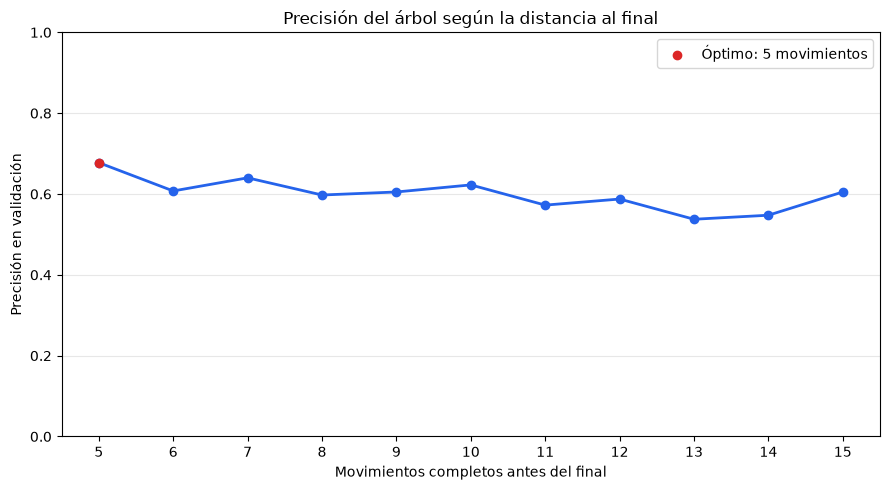

,movimientos_desde_final,numero_observaciones,precision
10,5,2000,0.6775
9,6,2000,0.6075
8,7,2000,0.6400
7,8,2000,0.5975
6,9,2000,0.6050
5,10,2000,0.6225
4,11,2000,0.5725
3,12,2000,0.5875
2,13,2000,0.5375
1,14,2000,0.5475


In [41]:
MOVIMIENTOS_DESDE_FINAL = range(15, 4, -1)
NUMERO_OBSERVACIONES_POR_HORIZONTE = 2000

resultados_horizonte = []
arboles_por_horizonte = {}

for movimientos_desde_final in MOVIMIENTOS_DESDE_FINAL:
    datos_horizonte = extrae_caracteristicas(
        PGN_ZST_PATH,
        numero_observaciones=NUMERO_OBSERVACIONES_POR_HORIZONTE,
        movimientos_desde_final=movimientos_desde_final,
    )

    X_horizonte = datos_horizonte[CARACTERISTICAS]
    y_horizonte = datos_horizonte["y"]

    X_train_horizonte, X_validation_horizonte, y_train_horizonte, y_validation_horizonte = train_test_split(
        X_horizonte,
        y_horizonte,
        test_size=0.2,
        random_state=42,
        stratify=y_horizonte,
    )

    arbol_horizonte = DecisionTreeClassifier(random_state=42)
    arbol_horizonte.fit(X_train_horizonte, y_train_horizonte)

    predicciones_horizonte = arbol_horizonte.predict(X_validation_horizonte)
    precision_horizonte = accuracy_score(
        y_validation_horizonte,
        predicciones_horizonte,
    )

    arboles_por_horizonte[movimientos_desde_final] = arbol_horizonte
    resultados_horizonte.append(
        {
            "movimientos_desde_final": movimientos_desde_final,
            "numero_observaciones": len(datos_horizonte),
            "precision": precision_horizonte,
        }
    )

resultados_horizonte = pd.DataFrame(resultados_horizonte).sort_values(
    "movimientos_desde_final"
)

horizonte_optimo = resultados_horizonte.loc[
    resultados_horizonte["precision"].idxmax(),
    "movimientos_desde_final",
]
precision_optima = resultados_horizonte["precision"].max()

print(
    f"Mejor horizonte: {horizonte_optimo} movimientos antes del final "
    f"({precision_optima:.2%})"
)

plt.figure(figsize=(9, 5))
plt.plot(
    resultados_horizonte["movimientos_desde_final"],
    resultados_horizonte["precision"],
    marker="o",
    linewidth=2,
    color="#2563eb",
)
plt.scatter(
    [horizonte_optimo],
    [precision_optima],
    color="#dc2626",
    zorder=3,
    label=f"Óptimo: {horizonte_optimo} movimientos",
)
plt.xticks(list(range(5, 16)))
plt.ylim(0, 1)
plt.xlabel("Movimientos completos antes del final")
plt.ylabel("Precisión en validación")
plt.title("Precisión del árbol según la distancia al final")
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

resultados_horizonte

In [16]:
X_observaciones = datos_observaciones[CARACTERISTICAS]
y_observaciones = datos_observaciones["y"]

X_train, X_validation, y_train, y_validation = train_test_split(
    X_observaciones,
    y_observaciones,
    test_size=0.2,
    random_state=42,
    stratify=y_observaciones,
)

arbol_decision = DecisionTreeClassifier(random_state=42)
arbol_decision.fit(X_train, y_train)

predicciones_validation = arbol_decision.predict(X_validation)
precision_validation = accuracy_score(y_validation, predicciones_validation)

print(f"Precisión en validación: {precision_validation:.2%}")
#precision_validation

Precisión en validación: 60.30%


In [17]:
param_grid_arbol = {
    "max_depth": [3, 5, 7, 10, None],
    "max_features": [None, "sqrt", "log2"],
    "min_samples_split": [2, 5, 10, 20],
}

grid_search_arbol = GridSearchCV(
    estimator=DecisionTreeClassifier(random_state=42),
    param_grid=param_grid_arbol,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)
grid_search_arbol.fit(X_train, y_train)

arbol_optimizado = grid_search_arbol.best_estimator_
predicciones_optimizado = arbol_optimizado.predict(X_validation)
precision_optimizada = accuracy_score(y_validation, predicciones_optimizado)

print(f"Mejores hiperparámetros: {grid_search_arbol.best_params_}")
print(f"Precisión media CV: {grid_search_arbol.best_score_:.2%}")
print(f"Precisión en validación: {precision_optimizada:.2%}")
print(f"Mejora frente al árbol base: {(precision_optimizada - precision_validation):+.2%}")

resultados_grid_arbol = (
    pd.DataFrame(grid_search_arbol.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_max_depth",
        "param_max_features",
        "param_min_samples_split",
    ]]
    .head(10)
)
resultados_grid_arbol

arbol_decision = arbol_optimizado
precision_validation = precision_optimizada

Mejores hiperparámetros: {'max_depth': 5, 'max_features': 'sqrt', 'min_samples_split': 20}
Precisión media CV: 68.35%
Precisión en validación: 68.10%
Mejora frente al árbol base: +7.80%


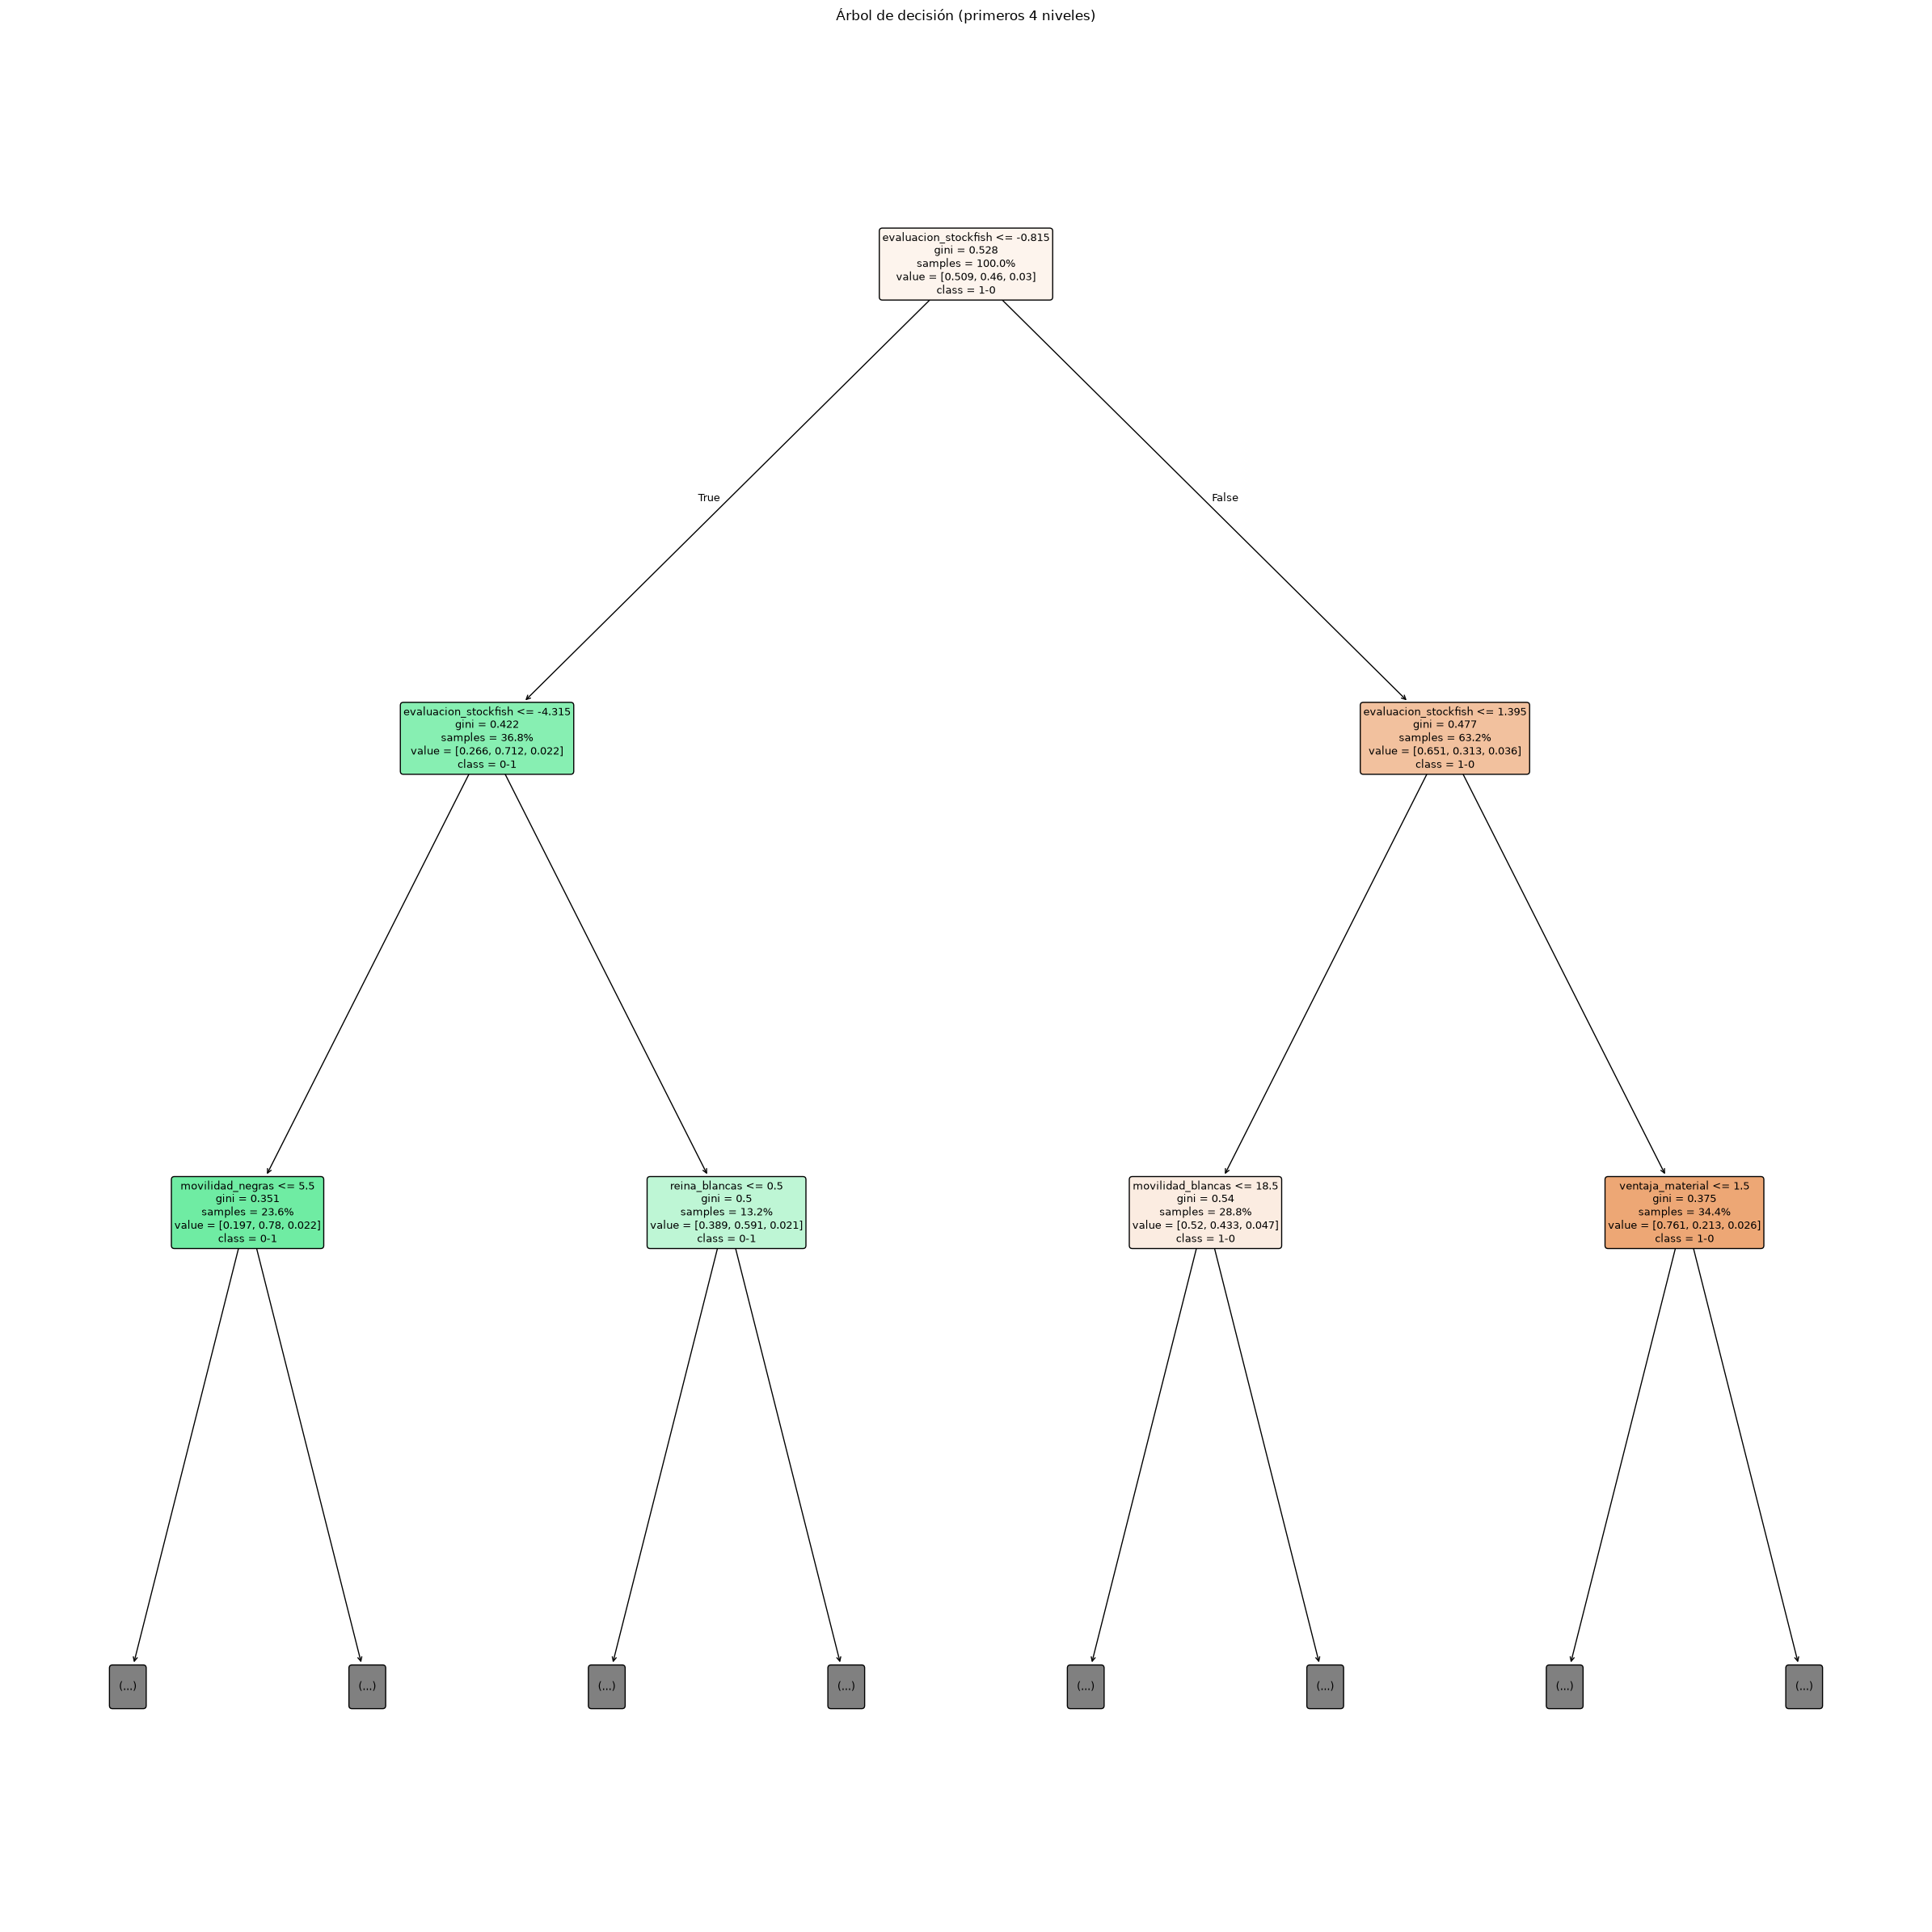

In [21]:


plt.figure(figsize=(24, 24))
plot_tree(
    arbol_decision,
    feature_names=CARACTERISTICAS,
    class_names=[resultado for resultado in RESULTADO_A_CLASE],
    filled=True,
    rounded=True,
    max_depth=2,
    impurity=True,
    proportion=True,
    fontsize=9,
)
plt.title("Árbol de decisión (primeros 4 niveles)")
plt.tight_layout()
plt.show()

In [34]:
INDICE_PARTIDA_PRUEBA = 5525
partida_prueba = partida_para_prueba(PGN_ZST_PATH, INDICE_PARTIDA_PRUEBA)
resultado_real = partida_prueba.headers.get("Result", "*")

if resultado_real not in RESULTADO_A_CLASE:
    raise ValueError(f"Resultado PGN no válido: {resultado_real}")

movimientos = list(partida_prueba.mainline_moves())
tablero = partida_prueba.board()
resultados_prueba = []
blancas_enrocadas = False
negras_enrocadas = False
motor_prueba = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_PATH))

try:
    # Solo se evalúan posiciones después de un movimiento completo (dos plies).
    # La última posición evaluada deja al menos 10 movimientos completos hasta el final.
    for inicio in range(0, len(movimientos) - 21, 2):
        for movimiento in movimientos[inicio:inicio + 2]:
            if tablero.is_castling(movimiento):
                if tablero.turn == chess.WHITE:
                    blancas_enrocadas = True
                else:
                    negras_enrocadas = True
            tablero.push(movimiento)

        caracteristicas = caracteristicas_con_stockfish(
            tablero,
            blancas_enrocadas,
            negras_enrocadas,
            motor_prueba,
        )
        X_posicion = pd.DataFrame([caracteristicas], columns=CARACTERISTICAS)
        prediccion = int(arbol_decision.predict(X_posicion)[0])

        resultados_prueba.append(
            {
                "movimiento_completo": tablero.fullmove_number - 1,
                "prediccion": prediccion,
                "resultado_real": RESULTADO_A_CLASE[resultado_real],
                "acierto": prediccion == RESULTADO_A_CLASE[resultado_real],
            }
        )
finally:
    motor_prueba.quit()

resultados_prueba = pd.DataFrame(resultados_prueba)

if resultados_prueba.empty:
    raise ValueError("La partida no tiene suficientes movimientos para esta evaluación")

aciertos_prueba = resultados_prueba["acierto"].sum()
numero_predicciones = len(resultados_prueba)
precision_prueba = resultados_prueba["acierto"].mean()

print(f"Partida evaluada: {INDICE_PARTIDA_PRUEBA}")
print(f"Resultado real: {resultado_real}")
print(f"Predicciones correctas: {aciertos_prueba}/{numero_predicciones}")
print(f"Precisión en la partida: {precision_prueba:.2%}")

resultados_prueba

Partida evaluada: 5525
Resultado real: 0-1
Predicciones correctas: 37/47
Precisión en la partida: 78.72%


,movimiento_completo,prediccion,resultado_real,acierto
0,1,0,1,False
1,2,0,1,False
2,3,0,1,False
3,4,0,1,False
4,5,0,1,False
5,6,0,1,False
6,7,1,1,True
7,8,1,1,True
8,9,1,1,True
9,10,1,1,True


In [9]:
param_grid_bosque = {
    "n_estimators": [100, 200],
    "max_depth": [5, 10, None],
    "max_features": ["sqrt", "log2", None],
    "min_samples_split": [2, 5, 10, 20],
}

grid_search_bosque = GridSearchCV(
    estimator=RandomForestClassifier(
        random_state=42,
        n_jobs=1,
    ),
    param_grid=param_grid_bosque,
    scoring="accuracy",
    cv=5,
    n_jobs=-1,
    return_train_score=True,
)
grid_search_bosque.fit(X_train, y_train)

bosque_aleatorio = grid_search_bosque.best_estimator_
predicciones_bosque = bosque_aleatorio.predict(X_validation)
precision_bosque = accuracy_score(y_validation, predicciones_bosque)

print(f"Mejores hiperparámetros del bosque: {grid_search_bosque.best_params_}")
print(f"Precisión media CV del bosque: {grid_search_bosque.best_score_:.2%}")
print(f"Precisión del árbol de decisión: {precision_validation:.2%}")
print(f"Precisión del random forest: {precision_bosque:.2%}")
print(f"Mejora del random forest: {(precision_bosque - precision_validation):+.2%}")

resultados_grid_bosque = (
    pd.DataFrame(grid_search_bosque.cv_results_)
    .sort_values("rank_test_score")
    [[
        "rank_test_score",
        "mean_test_score",
        "std_test_score",
        "mean_train_score",
        "param_n_estimators",
        "param_max_depth",
        "param_max_features",
        "param_min_samples_split",
    ]]
    .head(10)
)
resultados_grid_bosque

Mejores hiperparámetros del bosque: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_split': 20, 'n_estimators': 100}
Precisión media CV del bosque: 70.38%
Precisión del árbol de decisión: 68.10%
Precisión del random forest: 68.70%
Mejora del random forest: +0.60%


,rank_test_score,mean_test_score,std_test_score,mean_train_score,param_n_estimators,param_max_depth,param_max_features,param_min_samples_split
54,1,0.70375,0.016900,0.820688,100,None,sqrt,20
62,1,0.70375,0.016900,0.820688,100,None,log2,20
25,3,0.70325,0.018918,0.833812,200,10,sqrt,2
33,3,0.70325,0.018918,0.833812,200,10,log2,2
35,5,0.70225,0.016963,0.815375,200,10,log2,5
27,5,0.70225,0.016963,0.815375,200,10,sqrt,5
29,7,0.70200,0.016329,0.793375,200,10,sqrt,10
37,7,0.70200,0.016329,0.793375,200,10,log2,10
39,9,0.70200,0.013615,0.770625,200,10,log2,20
31,9,0.70200,0.013615,0.770625,200,10,sqrt,20


Importancia de las características según el random forest:


,caracteristica,importancia,importancia_porcentaje
0,evaluacion_stockfish,0.265487,26.548688
1,ventaja_material,0.180191,18.019071
2,movilidad_negras,0.158269,15.826876
3,movilidad_blancas,0.152736,15.273584
4,mas_piezas_negras,0.048697,4.869653
5,mas_piezas_blancas,0.042200,4.220032
6,dos_alfiles_blancas,0.015220,1.521978
7,negras_enrocadas,0.014751,1.475083
8,blancas_enrocadas,0.014640,1.464036
9,mas_peones_blancas,0.014516,1.451622


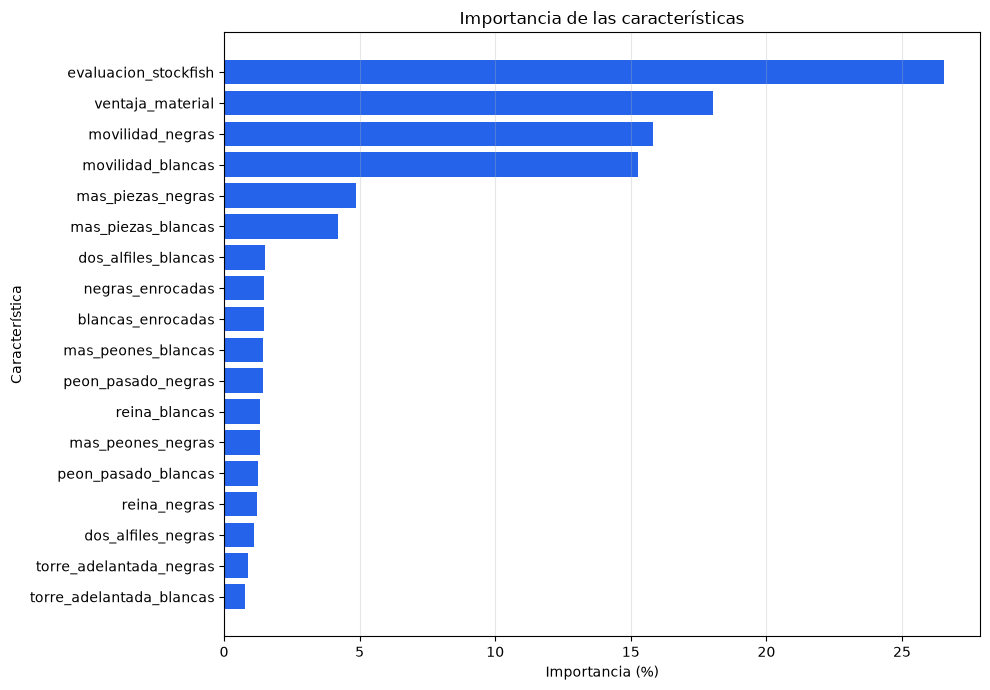

In [18]:
importancias_caracteristicas = pd.DataFrame(
    {
        "caracteristica": CARACTERISTICAS,
        "importancia": bosque_aleatorio.feature_importances_,
    }
).sort_values(
    "importancia",
    ascending=False,
    ignore_index=True,
)

importancias_caracteristicas["importancia_porcentaje"] = (
    importancias_caracteristicas["importancia"] * 100
)

print("Importancia de las características según el random forest:")
display(importancias_caracteristicas)

plt.figure(figsize=(10, 7))
plt.barh(
    importancias_caracteristicas["caracteristica"][::-1],
    importancias_caracteristicas["importancia_porcentaje"][::-1],
    color="#2563eb",
)
plt.xlabel("Importancia (%)")
plt.ylabel("Característica")
plt.title("Importancia de las características")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [38]:
modelo_random_forest = {
    "modelo": bosque_aleatorio,
    "caracteristicas": CARACTERISTICAS,
    "resultado_a_clase": RESULTADO_A_CLASE,
    "version_modelo": 1,
}

ruta_modelo = Path("modelo_chess_random_forest.joblib")
joblib.dump(modelo_random_forest, ruta_modelo)

print(f"Modelo guardado en: {ruta_modelo}")
print(f"Tamaño del archivo: {ruta_modelo.stat().st_size / 1024:.1f} KB")

Modelo guardado en: modelo_chess_random_forest.joblib
Tamaño del archivo: 4602.0 KB


In [19]:
INDICE_PARTIDA_PREDICCION = 35125
partida_prediccion = partida_para_prueba(PGN_ZST_PATH, INDICE_PARTIDA_PREDICCION)
resultado_real_prediccion = partida_prediccion.headers.get("Result", "*")

if resultado_real_prediccion not in RESULTADO_A_CLASE:
    raise ValueError(
        f"Resultado PGN no válido para clasificación: {resultado_real_prediccion}"
    )

movimientos_prediccion = list(partida_prediccion.mainline_moves())
tablero_prediccion = partida_prediccion.board()
resultados_prediccion = []
blancas_enrocadas_prediccion = False
negras_enrocadas_prediccion = False
motor_prediccion = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_PATH))

clase_a_resultado = {
    clase: resultado for resultado, clase in RESULTADO_A_CLASE.items()
}

try:
    # Se predice después de cada movimiento completo hasta dejar 10 movimientos al final.
    for inicio in range(0, len(movimientos_prediccion) - 21, 2):
        for movimiento in movimientos_prediccion[inicio:inicio + 2]:
            if tablero_prediccion.is_castling(movimiento):
                if tablero_prediccion.turn == chess.WHITE:
                    blancas_enrocadas_prediccion = True
                else:
                    negras_enrocadas_prediccion = True
            tablero_prediccion.push(movimiento)

        caracteristicas_prediccion = caracteristicas_con_stockfish(
            tablero_prediccion,
            blancas_enrocadas_prediccion,
            negras_enrocadas_prediccion,
            motor_prediccion,
        )
        X_posicion_prediccion = pd.DataFrame(
            [caracteristicas_prediccion],
            columns=CARACTERISTICAS,
        )
        prediccion = int(bosque_aleatorio.predict(X_posicion_prediccion)[0])
        resultado_predicho = clase_a_resultado[prediccion]

        resultados_prediccion.append(
            {
                "movimiento_completo": tablero_prediccion.fullmove_number - 1,
                "prediccion": resultado_predicho,
                "resultado_real": resultado_real_prediccion,
                "acierto": resultado_predicho == resultado_real_prediccion,
            }
        )
finally:
    motor_prediccion.quit()

resultados_prediccion = pd.DataFrame(resultados_prediccion)

if resultados_prediccion.empty:
    raise ValueError(
        "La partida no tiene suficientes movimientos para esta evaluación"
    )

print(f"Índice de la partida: {INDICE_PARTIDA_PREDICCION}")
print(f"Resultado real: {resultado_real_prediccion}")
print(
    f"Predicciones correctas: "
    f"{resultados_prediccion['acierto'].sum()}/"
    f"{len(resultados_prediccion)}"
)
print(
    f"Precisión del random forest con Stockfish en la partida: "
    f"{resultados_prediccion['acierto'].mean():.2%}"
)

resultados_prediccion

Índice de la partida: 35125
Resultado real: 1-0
Predicciones correctas: 7/38
Precisión del random forest con Stockfish en la partida: 18.42%


,movimiento_completo,prediccion,resultado_real,acierto
0,1,0-1,1-0,False
1,2,1-0,1-0,True
2,3,1-0,1-0,True
3,4,1-0,1-0,True
4,5,1-0,1-0,True
5,6,0-1,1-0,False
6,7,1-0,1-0,True
7,8,1-0,1-0,True
8,9,0-1,1-0,False
9,10,0-1,1-0,False


In [39]:
PGN_PREDICCIONES_PATH = Path("DB/predicciones.pgn.zst")
NUMERO_PARTIDAS = 20000

if not PGN_PREDICCIONES_PATH.exists():
    raise FileNotFoundError(f"No existe el archivo: {PGN_PREDICCIONES_PATH}")

clase_a_resultado = {
    clase: resultado for resultado, clase in RESULTADO_A_CLASE.items()
}
caracteristicas_1000_partidas = []
metadatos_1000_partidas = []
partidas_procesadas = 0
partidas_sin_prediccion = 0
motor_1000_partidas = chess.engine.SimpleEngine.popen_uci(str(STOCKFISH_PATH))

try:
    for indice_partida, partida in enumerate(partidas_en_stream(PGN_PREDICCIONES_PATH)):
        if indice_partida >= NUMERO_PARTIDAS:
            break

        resultado_real = partida.headers.get("Result", "*")
        if resultado_real not in RESULTADO_A_CLASE:
            continue

        movimientos = list(partida.mainline_moves())
        if len(movimientos) < 22:
            partidas_sin_prediccion += 1
            continue

        tablero = partida.board()
        blancas_enrocadas = False
        negras_enrocadas = False

        # Se llega a la posición que deja exactamente 10 movimientos completos al final.
        movimientos_a_reproducir = len(movimientos) - 20
        movimientos_a_reproducir -= movimientos_a_reproducir % 2

        for movimiento in movimientos[:movimientos_a_reproducir]:
            if tablero.is_castling(movimiento):
                if tablero.turn == chess.WHITE:
                    blancas_enrocadas = True
                else:
                    negras_enrocadas = True
            tablero.push(movimiento)

        caracteristicas_1000_partidas.append(
            caracteristicas_con_stockfish(
                tablero,
                blancas_enrocadas,
                negras_enrocadas,
                motor_1000_partidas,
            )
        )
        metadatos_1000_partidas.append(
            {
                "indice_partida": indice_partida,
                "movimientos_totales": len(movimientos),
                "movimiento_prediccion": tablero.fullmove_number - 1,
                "resultado_real": resultado_real,
            }
        )
        partidas_procesadas += 1
finally:
    motor_1000_partidas.quit()

if not caracteristicas_1000_partidas:
    raise ValueError("No se pudo generar ninguna posición de predicción")

X_1000_partidas = pd.DataFrame(
    caracteristicas_1000_partidas,
    columns=CARACTERISTICAS,
)
predicciones_1000 = bosque_aleatorio.predict(X_1000_partidas)

resultados_1000_partidas = pd.DataFrame(metadatos_1000_partidas)
resultados_1000_partidas["prediccion"] = [
    clase_a_resultado[int(clase)] for clase in predicciones_1000
]
resultados_1000_partidas["acierto"] = (
    resultados_1000_partidas["prediccion"]
    == resultados_1000_partidas["resultado_real"]
)

aciertos = int(resultados_1000_partidas["acierto"].sum())
numero_predicciones = len(resultados_1000_partidas)
precision_global = resultados_1000_partidas["acierto"].mean()

estadisticas_por_resultado = (
    resultados_1000_partidas.groupby("resultado_real")
    .agg(
        partidas=("indice_partida", "size"),
        aciertos=("acierto", "sum"),
        precision=("acierto", "mean"),
    )
    .reset_index()
)

matriz_predicciones = pd.crosstab(
    resultados_1000_partidas["resultado_real"],
    resultados_1000_partidas["prediccion"],
    rownames=["resultado_real"],
    colnames=["prediccion"],
)

print(f"Partidas válidas procesadas: {partidas_procesadas}")
print(f"Partidas sin predicción (< 11 movimientos): {partidas_sin_prediccion}")
print(f"Predicciones realizadas: {numero_predicciones}")
print(f"Aciertos: {aciertos}/{numero_predicciones}")
print(f"Precisión global: {precision_global:.2%}")
print("\nEstadísticas por resultado real:")
display(estadisticas_por_resultado)
print("\nMatriz de resultados reales frente a predichos:")
display(matriz_predicciones)

resultados_1000_partidas.head()

Partidas válidas procesadas: 18909
Partidas sin predicción (< 11 movimientos): 1091
Predicciones realizadas: 18909
Aciertos: 12510/18909
Precisión global: 66.16%

Estadísticas por resultado real:


,resultado_real,partidas,aciertos,precision
0,0-1,8613,6201,0.719958
1,1-0,9661,6266,0.648587
2,1/2-1/2,635,43,0.067717



Matriz de resultados reales frente a predichos:


prediccion,0-1,1-0,1/2-1/2
resultado_real,,,
0-1,6201,2392,20
1-0,3387,6266,8
1/2-1/2,338,254,43


,indice_partida,movimientos_totales,movimiento_prediccion,resultado_real,prediccion,acierto
0,0,33,6,1-0,0-1,False
1,1,43,11,1-0,1-0,True
2,3,71,25,1-0,0-1,False
3,5,52,16,0-1,0-1,True
4,6,27,3,1-0,1-0,True


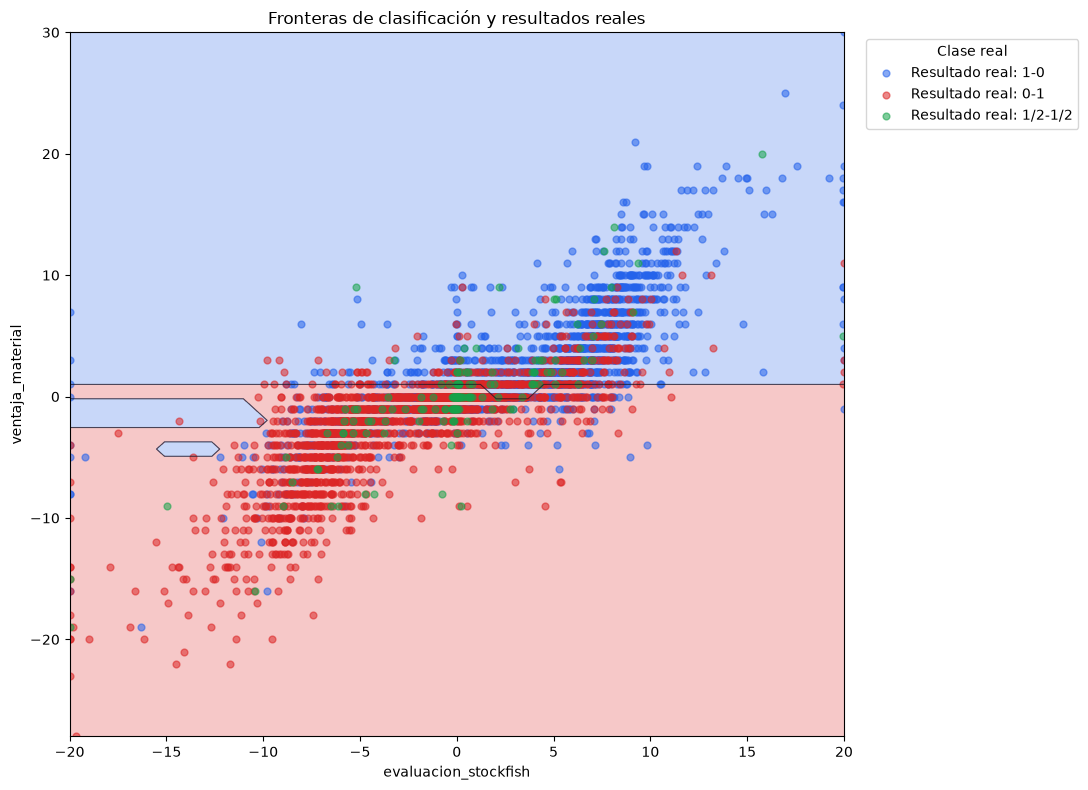

Características representadas: evaluacion_stockfish y ventaja_material
Resolución de la rejilla: 50x50


In [20]:
import matplotlib.colors as mcolors

NUMERO_PUNTOS_MALLA = 50

# Las dos características con mayor importancia según el random forest.
dos_caracteristicas_importantes = importancias_caracteristicas.head(2)[
    "caracteristica"
].tolist()
caracteristica_x, caracteristica_y = dos_caracteristicas_importantes

# Se fija el resto de características en su mediana de entrenamiento para obtener
# una sección bidimensional de la frontera del modelo.
valores_base = X_train.median(numeric_only=True).to_dict()
valores_x = np.linspace(
    X_train[caracteristica_x].min(),
    X_train[caracteristica_x].max(),
    NUMERO_PUNTOS_MALLA,
)
valores_y = np.linspace(
    X_train[caracteristica_y].min(),
    X_train[caracteristica_y].max(),
    NUMERO_PUNTOS_MALLA,
)
rejilla_x, rejilla_y = np.meshgrid(valores_x, valores_y)

puntos_rejilla = pd.DataFrame(
    np.tile(
        [valores_base[caracteristica] for caracteristica in CARACTERISTICAS],
        (NUMERO_PUNTOS_MALLA**2, 1),
    ),
    columns=CARACTERISTICAS,
)
puntos_rejilla[caracteristica_x] = rejilla_x.ravel()
puntos_rejilla[caracteristica_y] = rejilla_y.ravel()
predicciones_rejilla = bosque_aleatorio.predict(puntos_rejilla).reshape(
    rejilla_x.shape
)

colores_clases = ["#2563eb", "#dc2626", "#16a34a"]
mapa_colores = mcolors.ListedColormap(colores_clases)

X_todas = pd.concat([X_train, X_validation])
y_todas = pd.concat([y_train, y_validation])

plt.figure(figsize=(11, 8))
plt.contourf(
    rejilla_x,
    rejilla_y,
    predicciones_rejilla,
    levels=[-0.5, 0.5, 1.5, 2.5],
    cmap=mapa_colores,
    alpha=0.25,
)
plt.contour(
    rejilla_x,
    rejilla_y,
    predicciones_rejilla,
    levels=[0.5, 1.5],
    colors="#111827",
    linewidths=0.8,
    alpha=0.7,
)

for clase, resultado in sorted(
    ((clase, resultado) for resultado, clase in RESULTADO_A_CLASE.items()),
):
    mascara_real = y_todas == clase
    plt.scatter(
        X_todas.loc[mascara_real, caracteristica_x],
        X_todas.loc[mascara_real, caracteristica_y],
        c=colores_clases[clase],
        alpha=0.55,
        s=24,
        label=f"Resultado real: {resultado}",
    )

plt.xlabel(caracteristica_x)
plt.ylabel(caracteristica_y)
plt.title("Fronteras de clasificación y resultados reales")
plt.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xlim(valores_x.min(), valores_x.max())
plt.ylim(valores_y.min(), valores_y.max())
plt.tight_layout()
plt.show()

print(f"Características representadas: {caracteristica_x} y {caracteristica_y}")
print(f"Resolución de la rejilla: {NUMERO_PUNTOS_MALLA}x{NUMERO_PUNTOS_MALLA}")

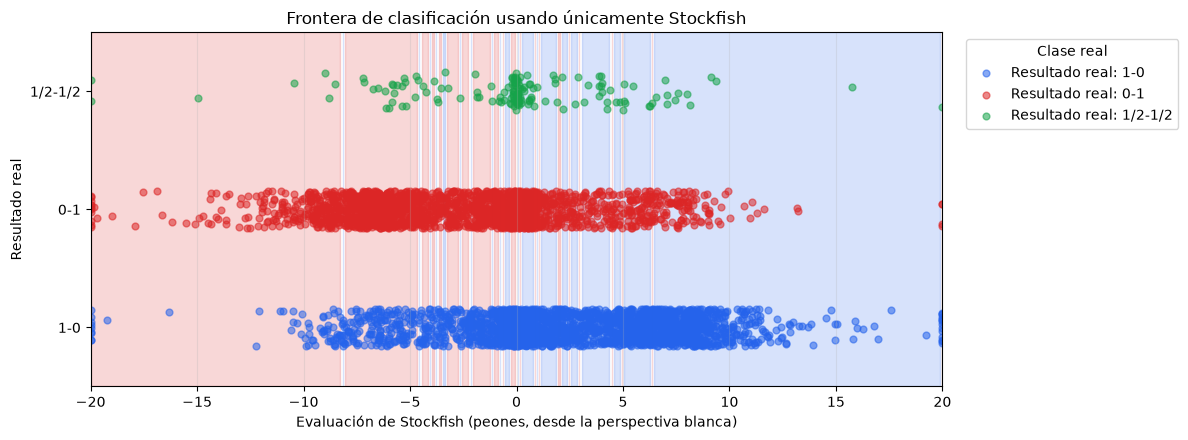

Precisión usando solo Stockfish en entrenamiento: 73.40%
Precisión usando solo Stockfish en validación: 62.60%


In [22]:
CARACTERISTICA_STOCKFISH = "evaluacion_stockfish"

X_train_stockfish = X_train[[CARACTERISTICA_STOCKFISH]]
X_validation_stockfish = X_validation[[CARACTERISTICA_STOCKFISH]]

parametros_stockfish = grid_search_bosque.best_params_.copy()
parametros_stockfish["n_jobs"] = 1
parametros_stockfish["random_state"] = 42
modelo_solo_stockfish = RandomForestClassifier(**parametros_stockfish)
modelo_solo_stockfish.fit(X_train_stockfish, y_train)

limite_inferior = X_train_stockfish[CARACTERISTICA_STOCKFISH].min()
limite_superior = X_train_stockfish[CARACTERISTICA_STOCKFISH].max()
valores_stockfish = np.linspace(limite_inferior, limite_superior, 400)
predicciones_stockfish = modelo_solo_stockfish.predict(
    pd.DataFrame({CARACTERISTICA_STOCKFISH: valores_stockfish})
)

colores_clases = ["#2563eb", "#dc2626", "#16a34a"]
figura, eje = plt.subplots(figsize=(12, 4.5))

# Cada tramo vertical representa la clase predicha usando solo Stockfish.
cambios_frontera = np.flatnonzero(predicciones_stockfish[1:] != predicciones_stockfish[:-1])
inicios_tramos = np.r_[0, cambios_frontera + 1]
finales_tramos = np.r_[cambios_frontera, len(valores_stockfish) - 1]
for inicio_tramo, final_tramo in zip(inicios_tramos, finales_tramos):
    clase_predicha = int(predicciones_stockfish[inicio_tramo])
    eje.axvspan(
        valores_stockfish[inicio_tramo],
        valores_stockfish[final_tramo],
        color=colores_clases[clase_predicha],
        alpha=0.18,
    )

X_todas_stockfish = pd.concat([X_train_stockfish, X_validation_stockfish])
y_todas_stockfish = pd.concat([y_train, y_validation])
generador_aleatorio = np.random.default_rng(42)

for clase, resultado in sorted(
    ((clase, resultado) for resultado, clase in RESULTADO_A_CLASE.items()),
):
    mascara_real = y_todas_stockfish == clase
    ruido_vertical = generador_aleatorio.uniform(-0.16, 0.16, mascara_real.sum())
    posiciones_y = np.full(mascara_real.sum(), clase, dtype=float) + ruido_vertical
    eje.scatter(
        X_todas_stockfish.loc[mascara_real, CARACTERISTICA_STOCKFISH],
        posiciones_y,
        color=colores_clases[clase],
        alpha=0.55,
        s=24,
        label=f"Resultado real: {resultado}",
    )

eje.set_xlabel("Evaluación de Stockfish (peones, desde la perspectiva blanca)")
eje.set_ylabel("Resultado real")
eje.set_yticks(list(RESULTADO_A_CLASE.values()))
eje.set_yticklabels(list(RESULTADO_A_CLASE.keys()))
eje.set_xlim(limite_inferior, limite_superior)
eje.set_ylim(-0.5, 2.5)
eje.set_title("Frontera de clasificación usando únicamente Stockfish")
eje.grid(axis="x", alpha=0.25)
eje.legend(title="Clase real", bbox_to_anchor=(1.02, 1), loc="upper left")
figura.tight_layout()
plt.show()

precision_stockfish_train = modelo_solo_stockfish.score(X_train_stockfish, y_train)
precision_stockfish_validation = modelo_solo_stockfish.score(
    X_validation_stockfish,
    y_validation,
)
print(f"Precisión usando solo Stockfish en entrenamiento: {precision_stockfish_train:.2%}")
print(f"Precisión usando solo Stockfish en validación: {precision_stockfish_validation:.2%}")